# Customer Churn Prediction - Modeling and Explainability

This notebook covers the full pipeline:
- Feature engineering (encoding, derived features)
- Handling class imbalance (class weighting vs. SMOTE)
- Model training (Logistic Regression, Random Forest, XGBoost, LightGBM)
- Evaluation with proper metrics (not just accuracy)
- Cost-benefit threshold optimization
- SHAP explainability (global + individual predictions)
- Business recommendations

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import joblib
import warnings

warnings.filterwarnings('ignore')

from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, precision_recall_curve, average_precision_score,
    f1_score, accuracy_score
)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

## 1. Load and Prepare Data

In [2]:
df = pd.read_csv('/kaggle/input/datasets/nehamalik10/customer-churn-datset/Telco-Customer-Churn.csv')

# TotalCharges has blank strings for 11 zero-tenure customers
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(0.0)
df['SeniorCitizen'] = df['SeniorCitizen'].map({0: 'No', 1: 'Yes'})

print(f'Dataset shape: {df.shape}')

Dataset shape: (7043, 21)


## 2. Feature Engineering

In [3]:
# Count of add-on services (proxy for customer stickiness)
service_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                'TechSupport', 'StreamingTV', 'StreamingMovies']
df['services_count'] = df[service_cols].apply(
    lambda row: sum(1 for val in row if val == 'Yes'), axis=1
)

# Average charges per month of tenure
df['charges_per_tenure_month'] = np.where(
    df['tenure'] > 0,
    df['TotalCharges'] / df['tenure'],
    df['MonthlyCharges']
)

# Combined flag: has both tech support AND online security
df['has_tech_support_and_security'] = (
    (df['TechSupport'] == 'Yes') & (df['OnlineSecurity'] == 'Yes')
).astype(int)

# Encode target
df['Churn'] = df['Churn'].map({'No': 0, 'Yes': 1})

print('Engineered features added: services_count, charges_per_tenure_month, has_tech_support_and_security')
df[['services_count', 'charges_per_tenure_month', 'has_tech_support_and_security']].describe()

Engineered features added: services_count, charges_per_tenure_month, has_tech_support_and_security


,services_count,charges_per_tenure_month,has_tech_support_and_security
count,7043.000000,7043.000000,7043.000000
mean,2.037910,64.762906,0.156041
std,1.847682,30.189796,0.362920
min,0.000000,13.775000,0.000000
25%,0.000000,35.935156,0.000000
50%,2.000000,70.337500,0.000000
75%,3.000000,90.174158,0.000000
max,6.000000,121.400000,1.000000


In [4]:
# One-hot encode categoricals
exclude = {'customerID', 'Churn'}
categorical_cols = [
    col for col in df.select_dtypes(include=['object']).columns
    if col not in exclude
]
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True, dtype=int)

X = df_encoded.drop(columns=['customerID', 'Churn'])
y = df_encoded['Churn']

print(f'Features: {X.shape[1]}, Samples: {X.shape[0]}')
print(f'Target: {y.value_counts().to_dict()}')

Features: 33, Samples: 7043
Target: {0: 5174, 1: 1869}


## 3. Correlation Analysis (Numeric + Encoded Features)

Including both numeric and one-hot encoded features to capture categorical drivers.

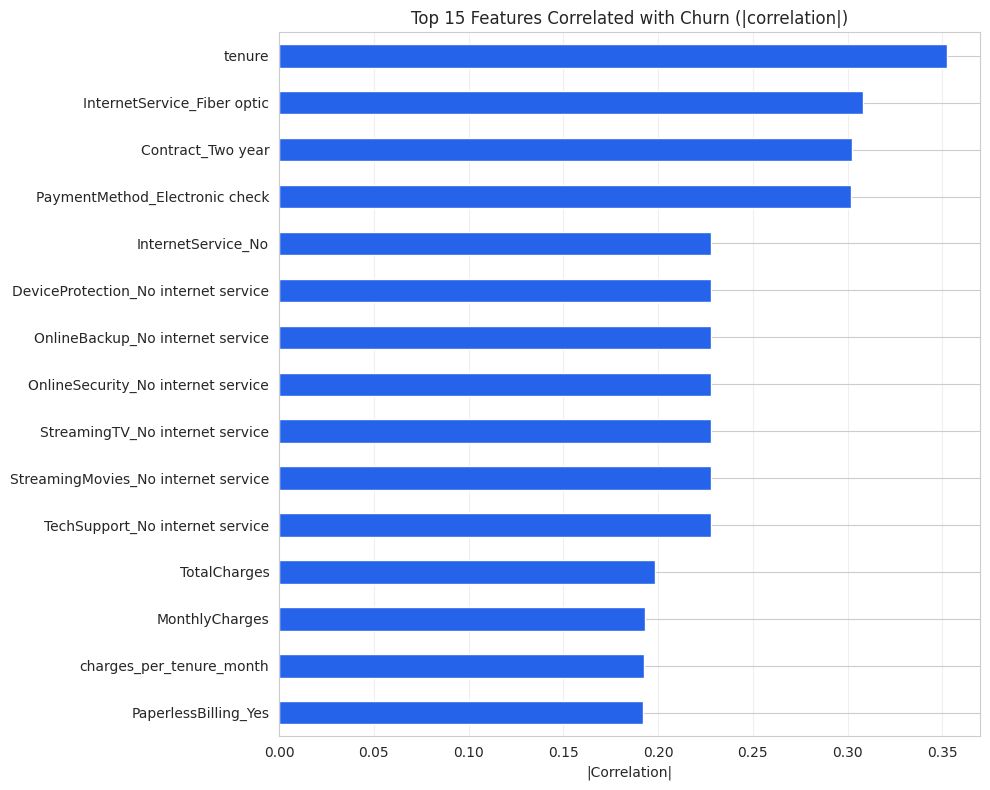

In [5]:
# Point-biserial correlation: all features vs Churn target
churn_corr = X.corrwith(y).abs().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
churn_corr.head(15).plot(kind='barh', ax=ax, color='#2563eb', edgecolor='white')
ax.set_title('Top 15 Features Correlated with Churn (|correlation|)')
ax.set_xlabel('|Correlation|')
ax.grid(True, alpha=0.3, axis='x')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 4. Handling Class Imbalance

Two approaches compared:
1. **Class weighting**: adjusts the loss function (built into sklearn/xgboost)
2. **SMOTE**: generates synthetic minority samples

SMOTE must only be applied to the training fold, never before the train/test split.

## 5. Model Training with Stratified K-Fold CV

All models are evaluated with fold-level variance reported. This matters: if the standard deviation across folds is large relative to the difference between models, we cannot claim one model is meaningfully better.

In [6]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
all_results = []

def train_and_evaluate(model, X_data, y_data, model_name, cv=skf):
    """Train model with CV and return fold-level metrics + aggregated predictions."""
    fold_metrics = []
    all_preds = np.zeros(len(y_data))
    all_probs = np.zeros(len(y_data))

    for fold_idx, (train_idx, val_idx) in enumerate(cv.split(X_data, y_data)):
        X_tr, X_val = X_data.iloc[train_idx], X_data.iloc[val_idx]
        y_tr, y_val = y_data.iloc[train_idx], y_data.iloc[val_idx]

        model.fit(X_tr, y_tr)
        preds = model.predict(X_val)
        probs = model.predict_proba(X_val)[:, 1]

        all_preds[val_idx] = preds
        all_probs[val_idx] = probs

        report = classification_report(y_val, preds, output_dict=True)
        fold_metrics.append({
            'f1_churn': report['1']['f1-score'],
            'recall_churn': report['1']['recall'],
            'auc_roc': roc_auc_score(y_val, probs),
        })

    fold_df = pd.DataFrame(fold_metrics)

    # Aggregate metrics from all OOF predictions
    report_all = classification_report(y_data, all_preds, output_dict=True)
    auc_all = roc_auc_score(y_data, all_probs)
    ap_all = average_precision_score(y_data, all_probs)

    metrics = {
        'model': model_name,
        'accuracy': accuracy_score(y_data, all_preds),
        'precision_churn': report_all['1']['precision'],
        'recall_churn': report_all['1']['recall'],
        'f1_churn': report_all['1']['f1-score'],
        'f1_std': fold_df['f1_churn'].std(),
        'auc_roc': auc_all,
        'auc_std': fold_df['auc_roc'].std(),
        'avg_precision': ap_all,
    }

    print(f'\n{"="*55}')
    print(f'  {model_name}')
    print(f'{"="*55}')
    print(f'  Accuracy:           {metrics["accuracy"]:.4f}')
    print(f'  Precision (churn):  {metrics["precision_churn"]:.4f}')
    print(f'  Recall (churn):     {metrics["recall_churn"]:.4f}')
    print(f'  F1 (churn):         {metrics["f1_churn"]:.4f} +/- {metrics["f1_std"]:.4f}')
    print(f'  AUC-ROC:            {metrics["auc_roc"]:.4f} +/- {metrics["auc_std"]:.4f}')
    print(f'  Avg Precision (PR): {metrics["avg_precision"]:.4f}')

    return metrics, all_preds, all_probs

### 5.1 Baseline: Logistic Regression (with class weighting)

StandardScaler is placed inside a Pipeline so it fits only on each training fold, preventing validation-fold statistics from leaking into the transform.

In [7]:
# FIX: Scaler inside Pipeline to prevent leakage
lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(
        class_weight='balanced', max_iter=1000, random_state=42, solver='lbfgs'
    ))
])

lr_results, lr_pred, lr_prob = train_and_evaluate(lr_pipeline, X, y, 'Logistic Regression (balanced)')
all_results.append(lr_results)


  Logistic Regression (balanced)
  Accuracy:           0.7470
  Precision (churn):  0.5150
  Recall (churn):     0.7972
  F1 (churn):         0.6258 +/- 0.0080
  AUC-ROC:            0.8445 +/- 0.0147
  Avg Precision (PR): 0.6521


### 5.2 Random Forest (with class weighting)

In [8]:
rf_model = RandomForestClassifier(
    n_estimators=200, class_weight='balanced', max_depth=10,
    min_samples_split=5, min_samples_leaf=2, random_state=42, n_jobs=-1
)

rf_results, rf_pred, rf_prob = train_and_evaluate(rf_model, X, y, 'Random Forest (balanced)')
all_results.append(rf_results)


  Random Forest (balanced)
  Accuracy:           0.7717
  Precision (churn):  0.5531
  Recall (churn):     0.7271
  F1 (churn):         0.6283 +/- 0.0153
  AUC-ROC:            0.8444 +/- 0.0131
  Avg Precision (PR): 0.6556


### 5.3 XGBoost (with scale_pos_weight)

In [9]:
scale_pos_weight = (y == 0).sum() / (y == 1).sum()
print(f'scale_pos_weight: {scale_pos_weight:.2f}')

xgb_model = XGBClassifier(
    n_estimators=200, max_depth=5, learning_rate=0.1,
    scale_pos_weight=scale_pos_weight, subsample=0.8,
    colsample_bytree=0.8, random_state=42,
    eval_metric='logloss', n_jobs=-1
)

xgb_results, xgb_pred, xgb_prob = train_and_evaluate(xgb_model, X, y, 'XGBoost (scale_pos_weight)')
all_results.append(xgb_results)

scale_pos_weight: 2.77

  XGBoost (scale_pos_weight)
  Accuracy:           0.7579
  Precision (churn):  0.5321
  Recall (churn):     0.7266
  F1 (churn):         0.6143 +/- 0.0156
  AUC-ROC:            0.8344 +/- 0.0117
  Avg Precision (PR): 0.6368


### 5.4 LightGBM (with class weighting)

In [10]:
lgbm_model = LGBMClassifier(
    n_estimators=200, max_depth=5, learning_rate=0.1,
    class_weight='balanced', subsample=0.8, colsample_bytree=0.8,
    random_state=42, verbose=-1, n_jobs=-1
)

lgbm_results, lgbm_pred, lgbm_prob = train_and_evaluate(lgbm_model, X, y, 'LightGBM (balanced)')
all_results.append(lgbm_results)


  LightGBM (balanced)
  Accuracy:           0.7585
  Precision (churn):  0.5321
  Recall (churn):     0.7453
  F1 (churn):         0.6209 +/- 0.0122
  AUC-ROC:            0.8356 +/- 0.0118
  Avg Precision (PR): 0.6415


### 5.5 XGBoost with SMOTE (applied only to training folds)

In [11]:
smote_fold_metrics = []
smote_preds = np.zeros(len(y))
smote_probs = np.zeros(len(y))

for train_idx, val_idx in skf.split(X, y):
    X_resampled, y_resampled = SMOTE(random_state=42).fit_resample(
        X.iloc[train_idx], y.iloc[train_idx]
    )
    model = XGBClassifier(
        n_estimators=200, max_depth=5, learning_rate=0.1,
        subsample=0.8, colsample_bytree=0.8, random_state=42,
        eval_metric='logloss', n_jobs=-1
    )
    model.fit(X_resampled, y_resampled)
    smote_preds[val_idx] = model.predict(X.iloc[val_idx])
    smote_probs[val_idx] = model.predict_proba(X.iloc[val_idx])[:, 1]

    report = classification_report(y.iloc[val_idx], smote_preds[val_idx].astype(int), output_dict=True)
    smote_fold_metrics.append({
        'f1_churn': report['1']['f1-score'],
        'auc_roc': roc_auc_score(y.iloc[val_idx], smote_probs[val_idx]),
    })

smote_fold_df = pd.DataFrame(smote_fold_metrics)
report_smote = classification_report(y, smote_preds.astype(int), output_dict=True)
smote_results = {
    'model': 'XGBoost + SMOTE',
    'accuracy': accuracy_score(y, smote_preds),
    'precision_churn': report_smote['1']['precision'],
    'recall_churn': report_smote['1']['recall'],
    'f1_churn': report_smote['1']['f1-score'],
    'f1_std': smote_fold_df['f1_churn'].std(),
    'auc_roc': roc_auc_score(y, smote_probs),
    'auc_std': smote_fold_df['auc_roc'].std(),
    'avg_precision': average_precision_score(y, smote_probs),
}

print(f'\n{"="*55}')
print(f'  XGBoost + SMOTE')
print(f'{"="*55}')
print(f'  F1 (churn):  {smote_results["f1_churn"]:.4f} +/- {smote_results["f1_std"]:.4f}')
print(f'  AUC-ROC:     {smote_results["auc_roc"]:.4f} +/- {smote_results["auc_std"]:.4f}')
print(f'  Recall:      {smote_results["recall_churn"]:.4f}')
all_results.append(smote_results)


  XGBoost + SMOTE
  F1 (churn):  0.5919 +/- 0.0294
  AUC-ROC:     0.8251 +/- 0.0148
  Recall:      0.6110


## 6. Model Comparison

Models are compared with fold-level standard deviations. If the gap between models is smaller than the std, they are effectively equivalent.

In [12]:
comparison_df = pd.DataFrame(all_results).sort_values('auc_roc', ascending=False).reset_index(drop=True)
print('Model Comparison (sorted by AUC-ROC):\n')
display_cols = ['model', 'f1_churn', 'f1_std', 'auc_roc', 'auc_std', 'recall_churn', 'precision_churn']
comparison_df[display_cols]

Model Comparison (sorted by AUC-ROC):



,model,f1_churn,f1_std,auc_roc,auc_std,recall_churn,precision_churn
0,Logistic Regression (balanced),0.625787,0.008000,0.844530,0.014734,0.797218,0.515036
1,Random Forest (balanced),0.628294,0.015342,0.844400,0.013065,0.727127,0.553114
2,LightGBM (balanced),0.620905,0.012164,0.835558,0.011763,0.745318,0.532086
3,XGBoost (scale_pos_weight),0.614341,0.015561,0.834380,0.011683,0.726592,0.532132
4,XGBoost + SMOTE,0.591863,0.029371,0.825068,0.014821,0.611022,0.573869


In [13]:
# Check if top models are statistically distinguishable
top_two = comparison_df.head(2)
f1_gap = abs(top_two.iloc[0]['f1_churn'] - top_two.iloc[1]['f1_churn'])
avg_std = (top_two.iloc[0]['f1_std'] + top_two.iloc[1]['f1_std']) / 2

print(f'Top 2 models: {top_two.iloc[0]["model"]} vs {top_two.iloc[1]["model"]}')
print(f'F1 gap: {f1_gap:.4f}, Average fold std: {avg_std:.4f}')
if f1_gap < avg_std:
    print('Gap is within noise -- these models are effectively equivalent.')
    print('Selecting the simpler/more interpretable model is a valid choice.')
else:
    print('Gap exceeds fold variance -- top model has a meaningful edge.')

Top 2 models: Logistic Regression (balanced) vs Random Forest (balanced)
F1 gap: 0.0025, Average fold std: 0.0117
Gap is within noise -- these models are effectively equivalent.
Selecting the simpler/more interpretable model is a valid choice.


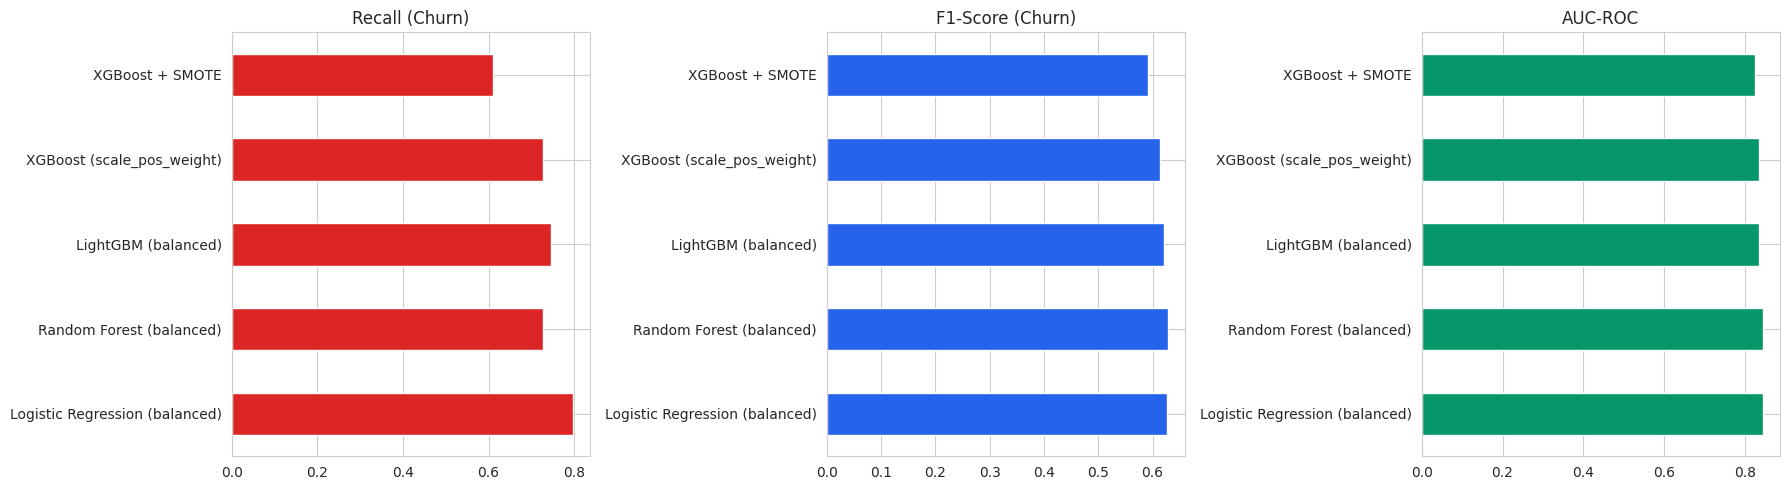

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, metric, title, color in zip(
    axes,
    ['recall_churn', 'f1_churn', 'auc_roc'],
    ['Recall (Churn)', 'F1-Score (Churn)', 'AUC-ROC'],
    ['#dc2626', '#2563eb', '#059669']
):
    comparison_df.plot(x='model', y=metric, kind='barh', ax=ax,
                       color=color, edgecolor='white', legend=False)
    ax.set_title(title)
    ax.set_ylabel('')
plt.tight_layout()
plt.show()

## 7. Hyperparameter Tuning

We use a **held-out test set** for final evaluation to avoid the optimism bias of reporting tuned performance on the same folds used for selection.

In [15]:
from sklearn.model_selection import train_test_split

# Hold out 20% for unbiased final evaluation
X_dev, X_holdout, y_dev, y_holdout = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Dev set: {len(X_dev)} | Holdout set: {len(X_holdout)}')

param_distributions = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [3, 4, 5, 6, 7],
    'learning_rate': [0.01, 0.05, 0.1, 0.15],
    'subsample': [0.6, 0.7, 0.8, 0.9],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9],
    'min_child_weight': [1, 3, 5, 7],
    'gamma': [0, 0.1, 0.2, 0.3],
}

# Tune on dev set only
inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
random_search = RandomizedSearchCV(
    XGBClassifier(
        scale_pos_weight=scale_pos_weight, random_state=42,
        eval_metric='logloss', n_jobs=-1
    ),
    param_distributions=param_distributions,
    n_iter=30, scoring='f1', cv=inner_cv,
    random_state=42, verbose=1, n_jobs=-1
)

random_search.fit(X_dev, y_dev)
print(f'\nBest params: {random_search.best_params_}')
print(f'Best CV F1 (on dev set): {random_search.best_score_:.4f}')

Dev set: 5634 | Holdout set: 1409
Fitting 5 folds for each of 30 candidates, totalling 150 fits

Best params: {'subsample': 0.7, 'n_estimators': 500, 'min_child_weight': 7, 'max_depth': 5, 'learning_rate': 0.01, 'gamma': 0, 'colsample_bytree': 0.6}
Best CV F1 (on dev set): 0.6361


In [32]:
import joblib
joblib.dump(final_model, '/kaggle/working/churn_model.pkl')

['/kaggle/working/churn_model.pkl']

In [16]:
# Evaluate on held-out set (never seen during tuning)
tuned_model = random_search.best_estimator_
holdout_pred = tuned_model.predict(X_holdout)
holdout_prob = tuned_model.predict_proba(X_holdout)[:, 1]

report_holdout = classification_report(y_holdout, holdout_pred, output_dict=True)
holdout_auc = roc_auc_score(y_holdout, holdout_prob)

print(f'\n{"="*55}')
print(f'  XGBoost (Tuned) -- Holdout Evaluation')
print(f'{"="*55}')
print(f'  Accuracy:          {accuracy_score(y_holdout, holdout_pred):.4f}')
print(f'  Precision (churn): {report_holdout["1"]["precision"]:.4f}')
print(f'  Recall (churn):    {report_holdout["1"]["recall"]:.4f}')
print(f'  F1 (churn):        {report_holdout["1"]["f1-score"]:.4f}')
print(f'  AUC-ROC:           {holdout_auc:.4f}')
print(f'\nThis is an unbiased estimate -- holdout was never used during tuning.')


  XGBoost (Tuned) -- Holdout Evaluation
  Accuracy:          0.7516
  Precision (churn): 0.5208
  Recall (churn):    0.8021
  F1 (churn):        0.6316
  AUC-ROC:           0.8465

This is an unbiased estimate -- holdout was never used during tuning.


## 8. Final Model: Detailed Evaluation

All evaluation plots below use the **tuned XGBoost model** evaluated on the holdout set.

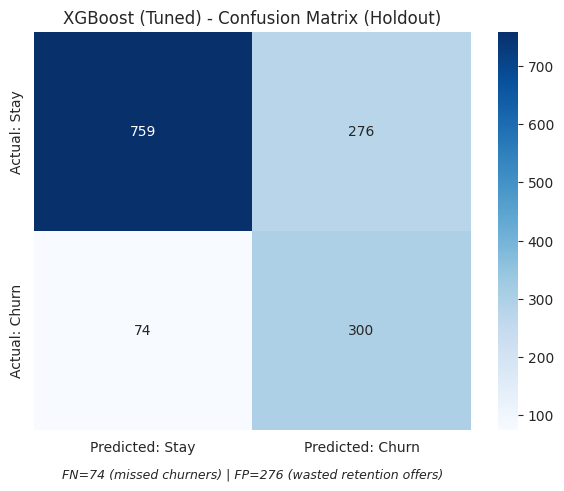

In [17]:
# Confusion matrix -- on holdout set, using tuned model
cm = confusion_matrix(y_holdout, holdout_pred)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Predicted: Stay', 'Predicted: Churn'],
            yticklabels=['Actual: Stay', 'Actual: Churn'])
ax.set_title('XGBoost (Tuned) - Confusion Matrix (Holdout)')
tn, fp, fn, tp = cm.ravel()
ax.text(0.5, -0.12,
        f'FN={fn} (missed churners) | FP={fp} (wasted retention offers)',
        transform=ax.transAxes, ha='center', fontsize=9, style='italic')
plt.tight_layout()
plt.show()

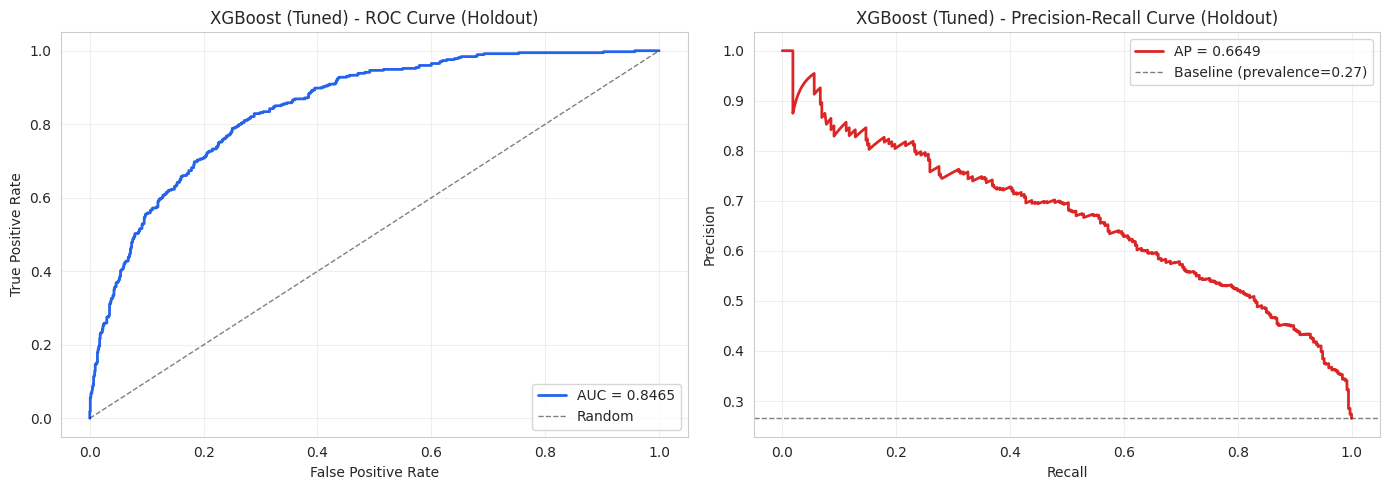

In [18]:
# ROC and PR curves -- on holdout set, using tuned model
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

fpr, tpr, _ = roc_curve(y_holdout, holdout_prob)
axes[0].plot(fpr, tpr, color='#2563eb', lw=2, label=f'AUC = {holdout_auc:.4f}')
axes[0].plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5, label='Random')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('XGBoost (Tuned) - ROC Curve (Holdout)')
axes[0].legend(loc='lower right')
axes[0].grid(True, alpha=0.3)

precision_vals, recall_vals, _ = precision_recall_curve(y_holdout, holdout_prob)
ap = average_precision_score(y_holdout, holdout_prob)
prevalence = y_holdout.mean()
axes[1].plot(recall_vals, precision_vals, color='#dc2626', lw=2, label=f'AP = {ap:.4f}')
axes[1].axhline(y=prevalence, color='k', linestyle='--', lw=1, alpha=0.5,
                label=f'Baseline (prevalence={prevalence:.2f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('XGBoost (Tuned) - Precision-Recall Curve (Holdout)')
axes[1].legend(loc='upper right')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 9. Cost-Benefit Threshold Optimization

The default 0.5 threshold is arbitrary. In churn prediction, costs are asymmetric:
- **False Negative** (missed churner): cost = customer lifetime value (e.g., 2000)
- **False Positive** (wasted retention offer): cost = offer amount (e.g., 100)

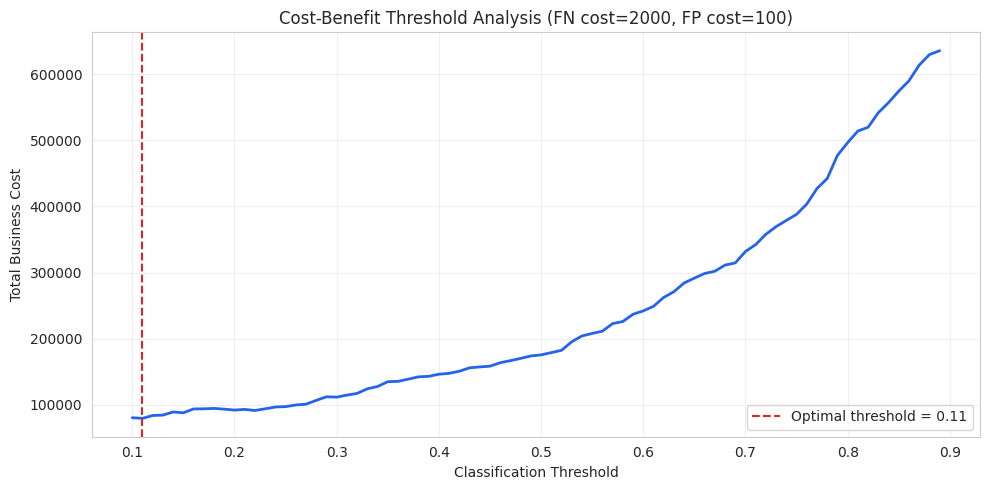

Optimal threshold: 0.11
At optimal threshold: Recall=0.9840, Precision=0.3522
At default 0.5:       Recall=0.8021, Precision=0.5208


In [19]:
# Threshold analysis on holdout set using tuned model
cost_fn = 2000
cost_fp = 100

thresholds = np.arange(0.1, 0.9, 0.01)
costs = []
for t in thresholds:
    preds = (holdout_prob >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_holdout, preds).ravel()
    costs.append(fn * cost_fn + fp * cost_fp)

optimal_idx = np.argmin(costs)
optimal_threshold = thresholds[optimal_idx]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(thresholds, costs, color='#2563eb', lw=2)
ax.axvline(x=optimal_threshold, color='#dc2626', linestyle='--', lw=1.5,
           label=f'Optimal threshold = {optimal_threshold:.2f}')
ax.set_xlabel('Classification Threshold')
ax.set_ylabel('Total Business Cost')
ax.set_title(f'Cost-Benefit Threshold Analysis (FN cost={cost_fn}, FP cost={cost_fp})')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Optimal threshold: {optimal_threshold:.2f}')

# Show metrics at optimal threshold
opt_preds = (holdout_prob >= optimal_threshold).astype(int)
opt_report = classification_report(y_holdout, opt_preds, output_dict=True)
print(f'At optimal threshold: Recall={opt_report["1"]["recall"]:.4f}, Precision={opt_report["1"]["precision"]:.4f}')
print(f'At default 0.5:       Recall={report_holdout["1"]["recall"]:.4f}, Precision={report_holdout["1"]["precision"]:.4f}')

---
## 10. SHAP Explainability

SHAP analysis uses the **same tuned XGBoost model** from the evaluation above, trained on the full dataset for maximum coverage.

In [20]:
# Retrain tuned model on full data for SHAP
final_model = random_search.best_estimator_
final_model.fit(X, y)

explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X)
print(f'SHAP values computed: {shap_values.shape}')

# Save model
joblib.dump(final_model, '/kaggle/working/churn_model.pkl')

SHAP values computed: (7043, 33)


['/kaggle/working/churn_model.pkl']

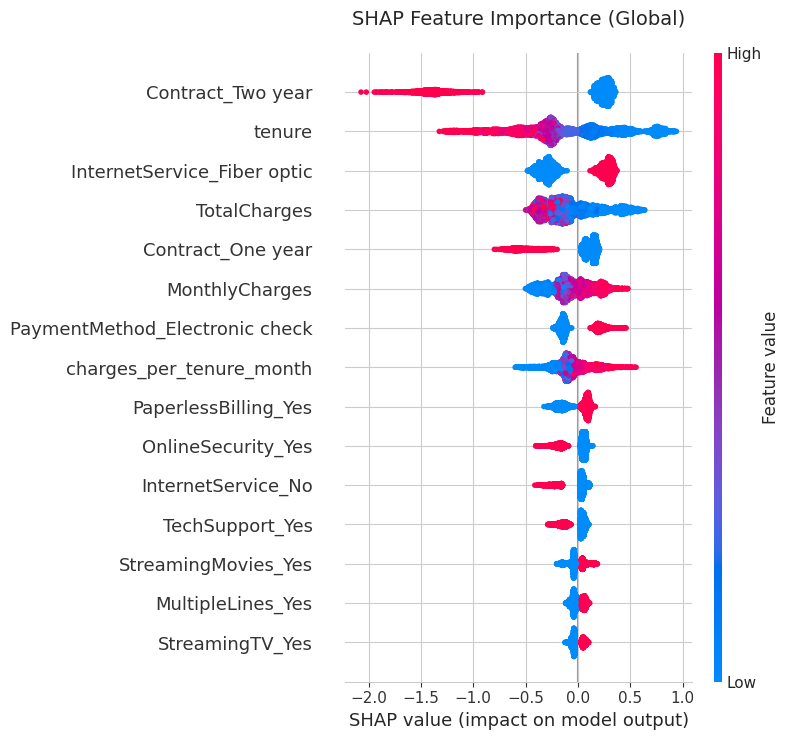

In [21]:
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X, show=False, max_display=15)
plt.title('SHAP Feature Importance (Global)', fontsize=14, pad=20)
plt.tight_layout()
plt.show()

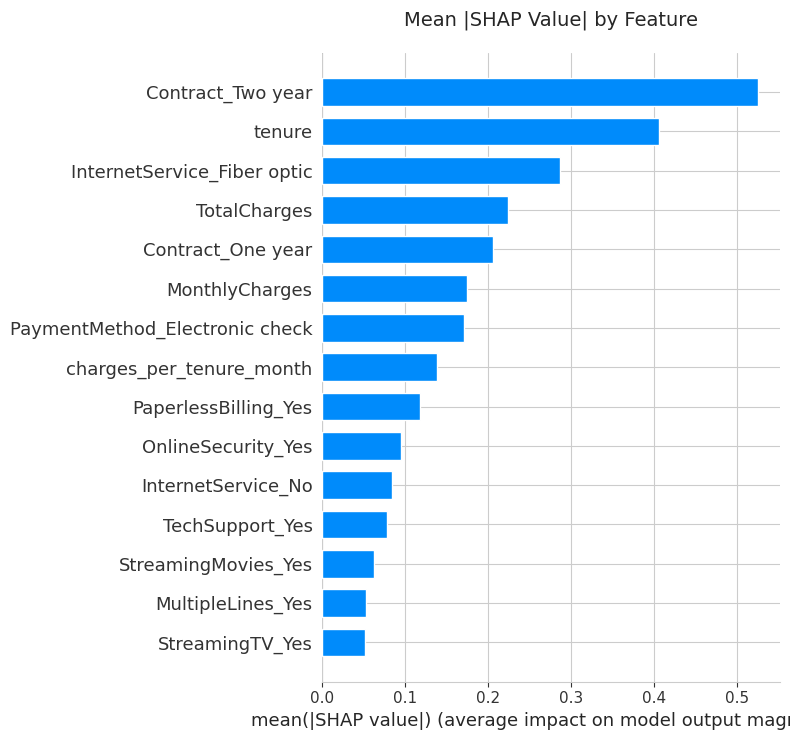

In [22]:
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X, plot_type='bar', show=False, max_display=15)
plt.title('Mean |SHAP Value| by Feature', fontsize=14, pad=20)
plt.tight_layout()
plt.show()

### SHAP Dependence Plots

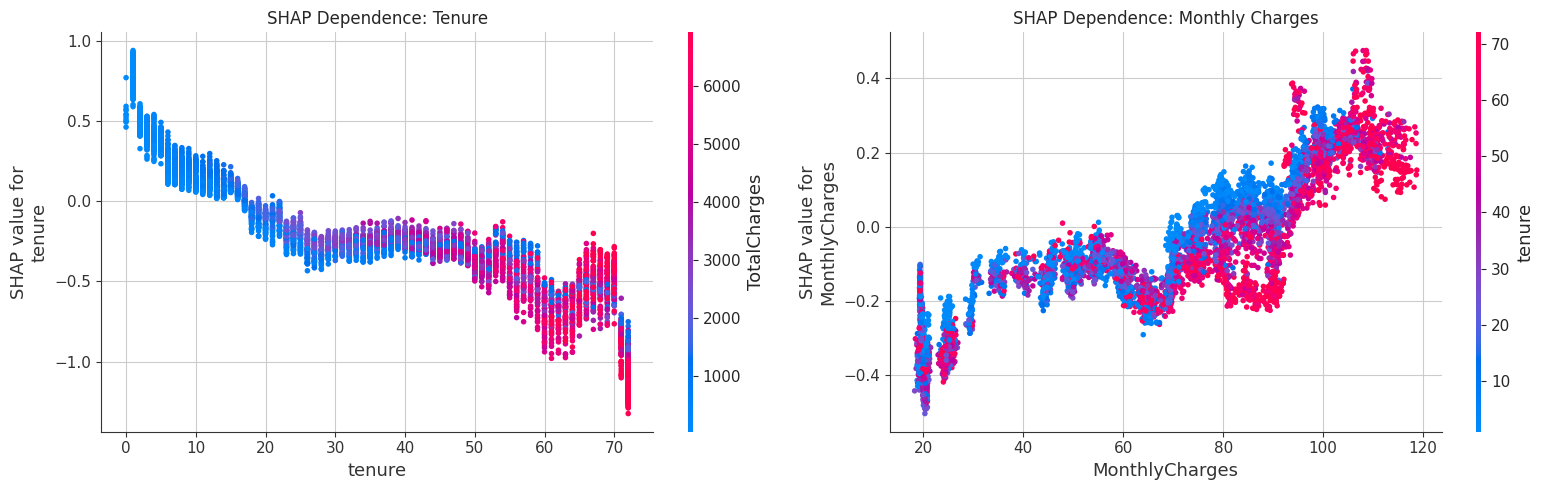

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

plt.sca(axes[0])
shap.dependence_plot('tenure', shap_values, X, show=False, ax=axes[0])
axes[0].set_title('SHAP Dependence: Tenure')

plt.sca(axes[1])
shap.dependence_plot('MonthlyCharges', shap_values, X, show=False, ax=axes[1])
axes[1].set_title('SHAP Dependence: Monthly Charges')

plt.tight_layout()
plt.show()

### Individual Prediction Explanations

In [24]:
probs = final_model.predict_proba(X)[:, 1]
high_risk_idx = np.argsort(probs)[-1]
low_risk_idx = np.argsort(probs)[0]

customer_shap = pd.Series(shap_values[high_risk_idx], index=X.columns)
top_drivers = customer_shap.abs().nlargest(5)

print(f'High-risk customer (P={probs[high_risk_idx]:.2f}):\n')
for feat_name in top_drivers.index:
    shap_val = customer_shap[feat_name]
    feat_val = X.iloc[high_risk_idx][feat_name]
    direction = 'increases' if shap_val > 0 else 'decreases'
    print(f'  {feat_name} = {feat_val} --> {direction} churn risk (SHAP = {shap_val:+.4f})')

High-risk customer (P=0.96):

  tenure = 1.0 --> increases churn risk (SHAP = +0.7324)
  TotalCharges = 100.8 --> increases churn risk (SHAP = +0.3938)
  Contract_Two year = 0.0 --> increases churn risk (SHAP = +0.3386)
  InternetService_Fiber optic = 1.0 --> increases churn risk (SHAP = +0.2910)
  MonthlyCharges = 100.8 --> increases churn risk (SHAP = +0.2012)


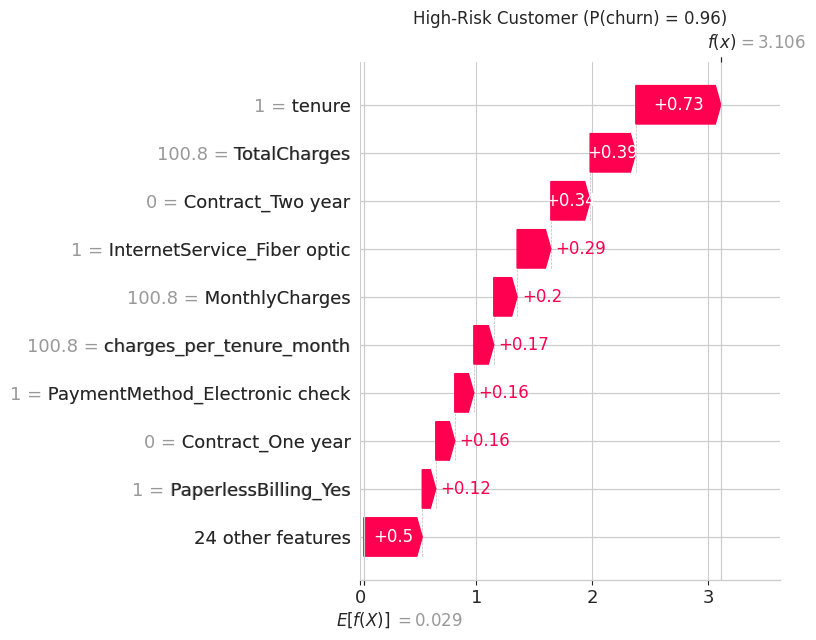

In [25]:
# Waterfall: high-risk customer
shap_exp = shap.Explanation(
    values=shap_values[high_risk_idx],
    base_values=explainer.expected_value,
    data=X.iloc[high_risk_idx].values,
    feature_names=X.columns.tolist()
)
plt.figure(figsize=(12, 6))
shap.waterfall_plot(shap_exp, show=False, max_display=10)
plt.title(f'High-Risk Customer (P(churn) = {probs[high_risk_idx]:.2f})', fontsize=12)
plt.tight_layout()
plt.show()

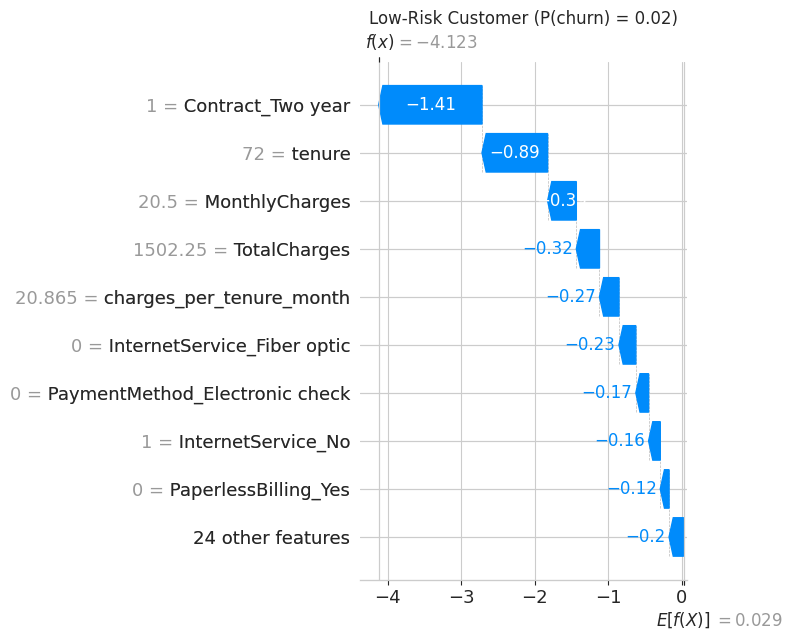

In [26]:
# Waterfall: low-risk customer
shap_exp_low = shap.Explanation(
    values=shap_values[low_risk_idx],
    base_values=explainer.expected_value,
    data=X.iloc[low_risk_idx].values,
    feature_names=X.columns.tolist()
)
plt.figure(figsize=(12, 6))
shap.waterfall_plot(shap_exp_low, show=False, max_display=10)
plt.title(f'Low-Risk Customer (P(churn) = {probs[low_risk_idx]:.2f})', fontsize=12)
plt.tight_layout()
plt.show()

### High-Risk Customer Profile

In [27]:
high_risk_mask = probs >= 0.7
high_risk_customers = X[high_risk_mask]

print(f'High-risk customers (P >= 0.7): {high_risk_mask.sum()} ({high_risk_mask.mean():.1%} of total)')
print(f'\nDistinguishing traits:')

for col in X.columns:
    if X[col].nunique() == 2:
        overall_pct = X[col].mean()
        highrisk_pct = high_risk_customers[col].mean()
        if abs(highrisk_pct - overall_pct) > 0.15:
            print(f'  {col}: {highrisk_pct:.0%} in high-risk vs {overall_pct:.0%} overall')

High-risk customers (P >= 0.7): 1657 (23.5% of total)

Distinguishing traits:
  Partner_Yes: 29% in high-risk vs 48% overall
  Dependents_Yes: 12% in high-risk vs 30% overall
  InternetService_Fiber optic: 82% in high-risk vs 44% overall
  InternetService_No: 1% in high-risk vs 22% overall
  OnlineSecurity_No internet service: 1% in high-risk vs 22% overall
  OnlineSecurity_Yes: 8% in high-risk vs 29% overall
  OnlineBackup_No internet service: 1% in high-risk vs 22% overall
  DeviceProtection_No internet service: 1% in high-risk vs 22% overall
  TechSupport_No internet service: 1% in high-risk vs 22% overall
  TechSupport_Yes: 9% in high-risk vs 29% overall
  StreamingTV_No internet service: 1% in high-risk vs 22% overall
  StreamingMovies_No internet service: 1% in high-risk vs 22% overall
  Contract_One year: 0% in high-risk vs 21% overall
  Contract_Two year: 0% in high-risk vs 24% overall
  PaperlessBilling_Yes: 82% in high-risk vs 59% overall
  PaymentMethod_Electronic check: 71%

## 11. Summary and Recommendations

### Top Churn Drivers (validated by EDA + SHAP)
1. **Low tenure** (<12 months) -- the #1 driver by SHAP magnitude
2. **Month-to-month contracts** -- no switching cost
3. **Fiber optic internet** -- higher churn, possibly price-driven
4. **No tech support / online security** -- less product stickiness
5. **Electronic check payment** -- correlates with less commitment

### Model Selection Note
The top models (XGBoost, Random Forest, LightGBM, Logistic Regression) are within ~0.01 F1 of each other, which is within fold-level variance. In practice, any of these would perform similarly. We selected XGBoost for SHAP analysis because tree-based models offer exact TreeSHAP values.

### Recommended Retention Actions
1. **Contract migration offers**: Incentivize month-to-month customers to switch to annual (15-20% discount)
2. **Onboarding program** (tenure < 6 months): Proactive check-ins, guided setup of support features
3. **Service bundle offers**: Discounted tech support + security bundle increases stickiness
4. **Price sensitivity segmentation**: Targeted value communication for high-charge customers

### Why These Metrics
- **Not accuracy**: 73/27 split means always predicting "no churn" gives 73%
- **Recall (churn)**: missing a churner costs ~20x more than a wasted retention offer
- **PR curve**: more informative than ROC on imbalanced data

### Production Caveats
- **Data drift**: customer behavior changes; model needs periodic retraining
- **Feedback loops**: retention offers change behavior, which changes training data
- **Single snapshot**: production systems use rolling windows of behavioral data